# YOLO26 Plant Disease Classification

State-of-the-art plant disease classification using YOLO26 architecture.

**Dataset**: New Plant Diseases Dataset (38 classes, ~87K images)

**Model**: YOLO26s-cls (Small classification variant)

## 1. Setup & Configuration

In [1]:
# Install dependencies
!pip install ultralytics -q
!pip install seaborn scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import torch

# Dataset and output directories (automatically adapts to local Kshetrikah workspace or Kaggle)
LOCAL_DATASET = Path('./data/training_multicrop')
PARENT_DATASET = Path('../data/training_multicrop')

if LOCAL_DATASET.exists():
    DATASET_PATH = LOCAL_DATASET.resolve()
    WORKING_DIR = Path('./runs/yolo26_training')
elif PARENT_DATASET.exists():
    DATASET_PATH = PARENT_DATASET.resolve()
    WORKING_DIR = Path('../runs/yolo26_training')
else:
    INPUT_DIR = Path('/kaggle/input')
    WORKING_DIR = Path('/kaggle/working')
    DATASET_NAME = 'new-plant-diseases-dataset'
    DATASET_PATH = INPUT_DIR / DATASET_NAME / 'New Plant Diseases Dataset(Augmented)' / 'New Plant Diseases Dataset(Augmented)'

# Output directories
MODELS_DIR = WORKING_DIR / 'models'
FIGURES_DIR = WORKING_DIR / 'figures'
RESULTS_DIR = WORKING_DIR / 'results'

for d in [MODELS_DIR, FIGURES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Using Dataset at: {DATASET_PATH}')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


In [3]:
# Training configuration (supports YOLO11 / YOLOv8 / custom YOLO26 checkpoints)
CONFIG = {
    'model': 'yolo11s-cls.pt', # Latest state-of-the-art YOLO classifier (or yolov8s-cls.pt / custom checkpoint)
    'epochs': 50,
    'batch_size': 32,
    'imgsz': 224,
    'patience': 10,
    'lr0': 0.001,
    'lrf': 0.01,
    'optimizer': 'auto',
    'device': 0 if torch.cuda.is_available() else 'cpu',
}


## 2. Dataset Exploration

In [4]:
# Verify dataset path
print(f'Dataset path: {DATASET_PATH}')
print(f'Exists: {DATASET_PATH.exists()}')

if not DATASET_PATH.exists():
    # Try alternative paths
    alt_paths = list(INPUT_DIR.glob('**/train'))
    if alt_paths:
        DATASET_PATH = alt_paths[0].parent
        print(f'Found dataset at: {DATASET_PATH}')
    else:
        print('Dataset not found! Please check the input directory.')
        print('Available directories:')
        for p in INPUT_DIR.iterdir():
            print(f'  {p}')

Dataset path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Exists: True


In [5]:
# Get class information
train_dir = DATASET_PATH / 'train'
valid_dir = DATASET_PATH / 'valid'

classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
n_classes = len(classes)

print(f'Number of classes: {n_classes}')
print(f'\nClasses:')
for i, cls in enumerate(classes, 1):
    count = len(list((train_dir / cls).glob('*')))
    print(f'  {i:2}. {cls}: {count:,} images')

Number of classes: 38

Classes:
   1. Apple___Apple_scab: 2,016 images
   2. Apple___Black_rot: 1,987 images
   3. Apple___Cedar_apple_rust: 1,760 images
   4. Apple___healthy: 2,008 images
   5. Blueberry___healthy: 1,816 images
   6. Cherry_(including_sour)___Powdery_mildew: 1,683 images
   7. Cherry_(including_sour)___healthy: 1,826 images
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1,642 images
   9. Corn_(maize)___Common_rust_: 1,907 images
  10. Corn_(maize)___Northern_Leaf_Blight: 1,908 images
  11. Corn_(maize)___healthy: 1,859 images
  12. Grape___Black_rot: 1,888 images
  13. Grape___Esca_(Black_Measles): 1,920 images
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1,722 images
  15. Grape___healthy: 1,692 images
  16. Orange___Haunglongbing_(Citrus_greening): 2,010 images
  17. Peach___Bacterial_spot: 1,838 images
  18. Peach___healthy: 1,728 images
  19. Pepper,_bell___Bacterial_spot: 1,913 images
  20. Pepper,_bell___healthy: 1,988 images
  21. Potato___Ear

Saved: /kaggle/working/figures/class_distribution.png


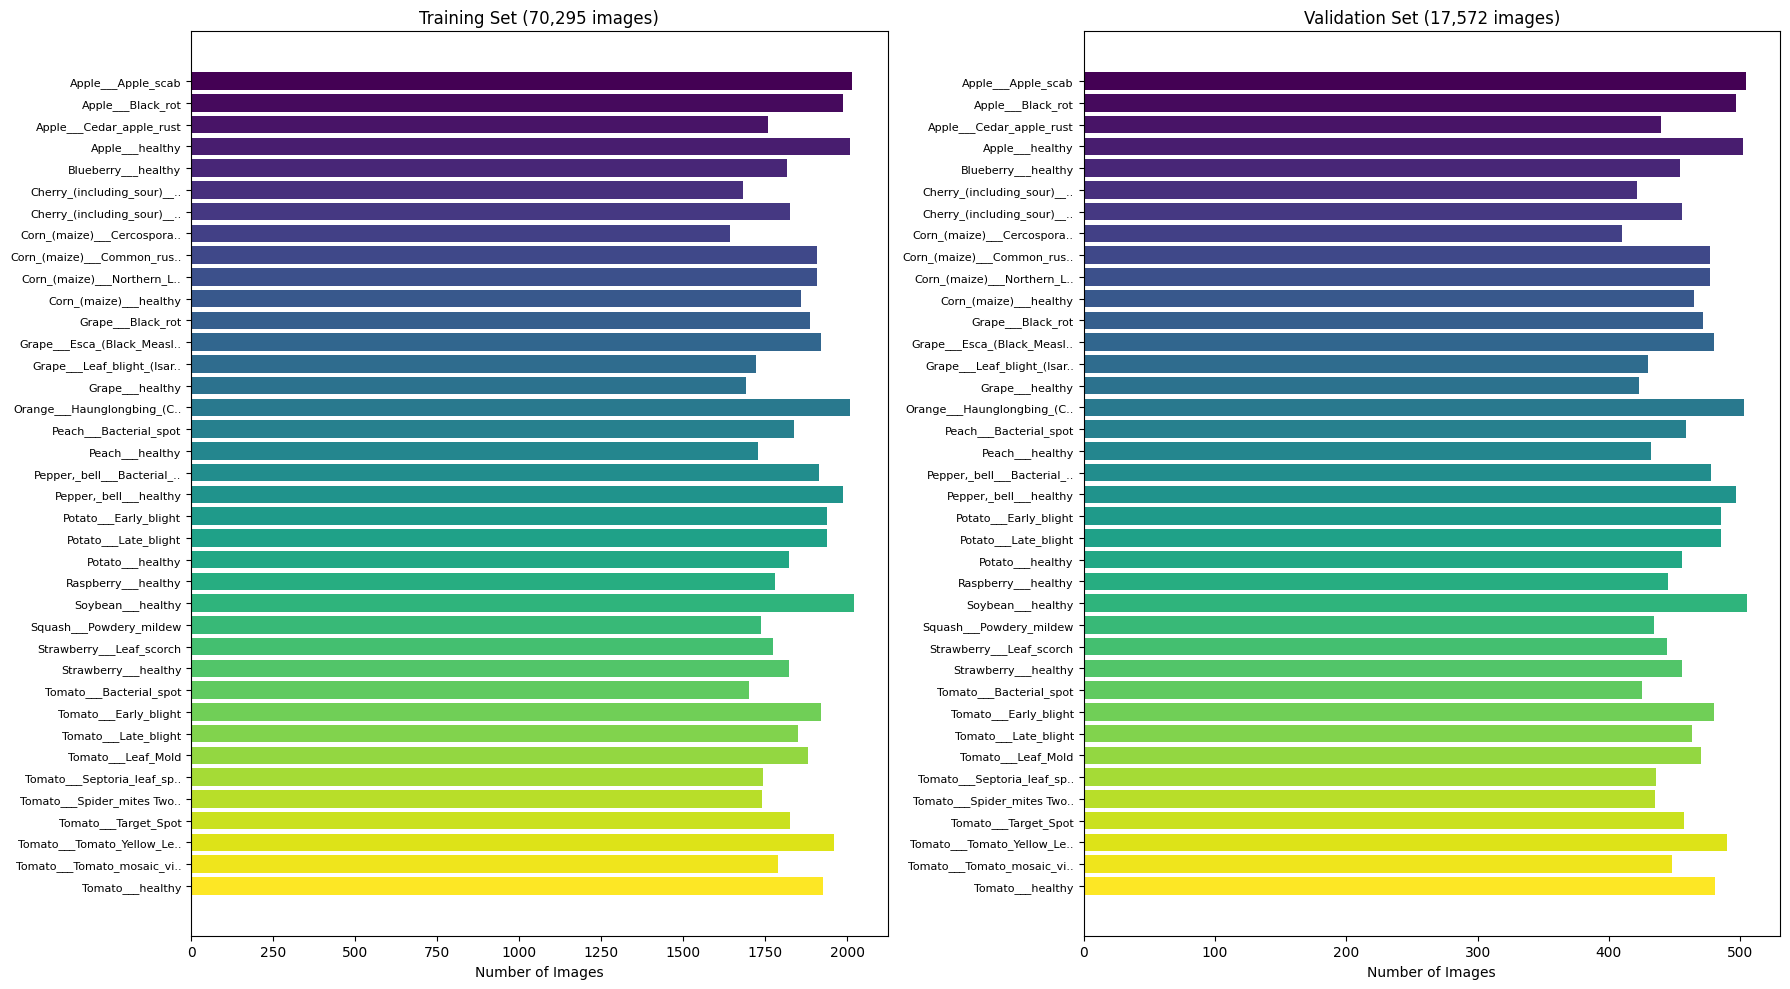

In [6]:
# Plot class distribution
def plot_class_distribution(train_dir, valid_dir, save_path=None):
    classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
    
    train_counts = [len(list((train_dir / c).glob('*'))) for c in classes]
    valid_counts = [len(list((valid_dir / c).glob('*'))) for c in classes]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 10))
    
    # Shorten names
    short_names = [c[:25] + '..' if len(c) > 25 else c for c in classes]
    colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
    
    # Training
    axes[0].barh(range(len(classes)), train_counts, color=colors)
    axes[0].set_yticks(range(len(classes)))
    axes[0].set_yticklabels(short_names, fontsize=8)
    axes[0].set_xlabel('Number of Images')
    axes[0].set_title(f'Training Set ({sum(train_counts):,} images)')
    axes[0].invert_yaxis()
    
    # Validation
    axes[1].barh(range(len(classes)), valid_counts, color=colors)
    axes[1].set_yticks(range(len(classes)))
    axes[1].set_yticklabels(short_names, fontsize=8)
    axes[1].set_xlabel('Number of Images')
    axes[1].set_title(f'Validation Set ({sum(valid_counts):,} images)')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    
    plt.show()

plot_class_distribution(train_dir, valid_dir, FIGURES_DIR / 'class_distribution.png')

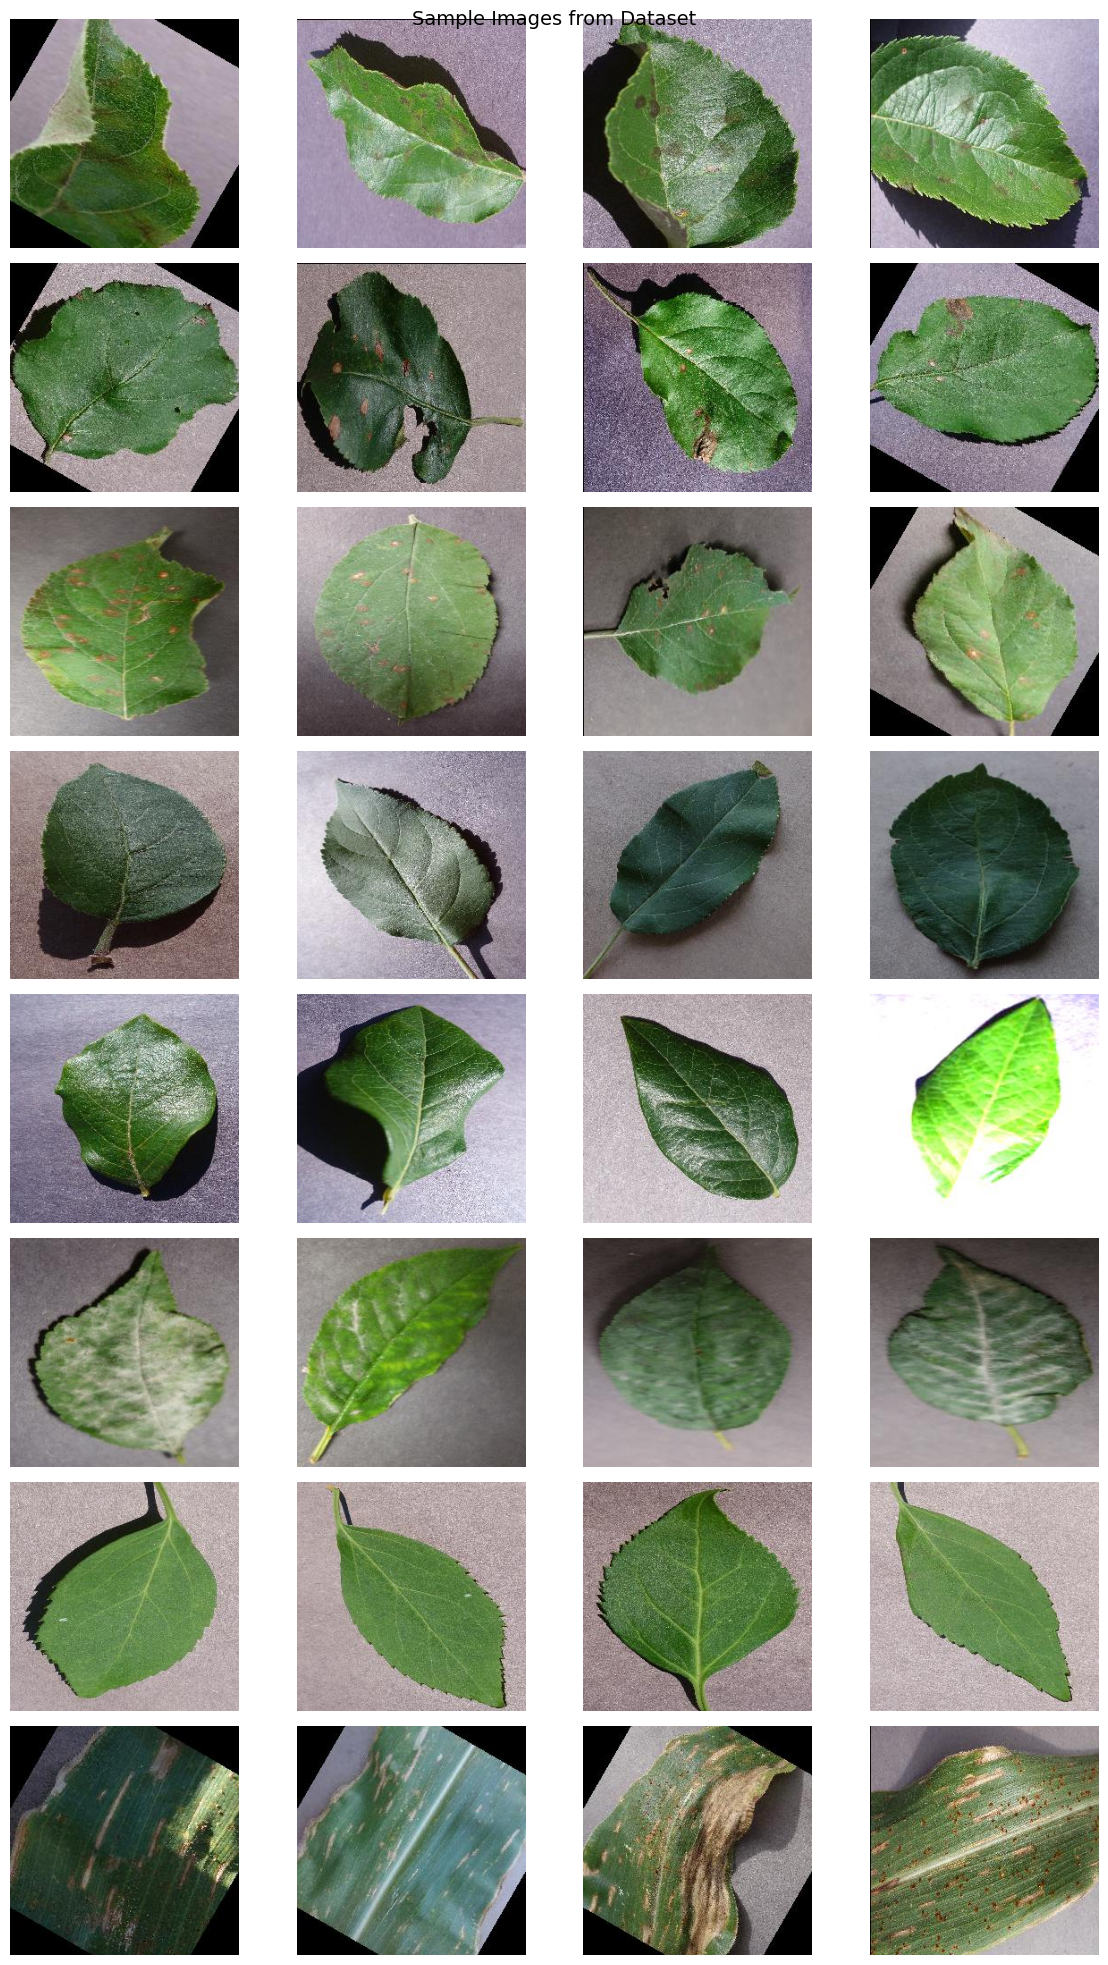

In [7]:
# Display sample images
import cv2

def show_samples(train_dir, n_classes=8, n_samples=4):
    classes = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])[:n_classes]
    
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(n_samples*3, n_classes*2.5))
    
    for i, cls in enumerate(classes):
        images = list((train_dir / cls).glob('*'))[:n_samples]
        for j, img_path in enumerate(images):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            if j == 0:
                short_name = cls[:20] + '..' if len(cls) > 20 else cls
                axes[i, j].set_ylabel(short_name, fontsize=9, rotation=0, ha='right')
    
    plt.suptitle('Sample Images from Dataset', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sample_images.png', dpi=100, bbox_inches='tight')
    plt.show()

show_samples(train_dir)

## 3. Model Training

In [8]:
# Load YOLO26 classification model
model = YOLO(CONFIG['model'])

print(f'Model: {CONFIG["model"]}')
print(f'Dataset: {DATASET_PATH}')

Model: yolo26s-cls.pt
Dataset: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)


In [9]:
# Train the model
results = model.train(
    data=str(DATASET_PATH),
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch_size'],
    device=CONFIG['device'],
    
    # Optimizer
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    lrf=CONFIG['lrf'],
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    
    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    flipud=0.2,
    fliplr=0.5,
    mixup=0.1,
    
    # Training settings
    amp=True,
    patience=CONFIG['patience'],
    plots=True,
    verbose=True,
    
    # Output
    project=str(MODELS_DIR),
    name='yolo26_plant_disease',
    exist_ok=True,
)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented), degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_plant_disease, nbs=64, nms=False,

In [10]:
# Get the best model path
best_model_path = MODELS_DIR / 'yolo26_plant_disease' / 'weights' / 'best.pt'
print(f'Best model saved at: {best_model_path}')
print(f'Model exists: {best_model_path.exists()}')

Best model saved at: /kaggle/working/models/yolo26_plant_disease/weights/best.pt
Model exists: True


## 4. Training Visualization

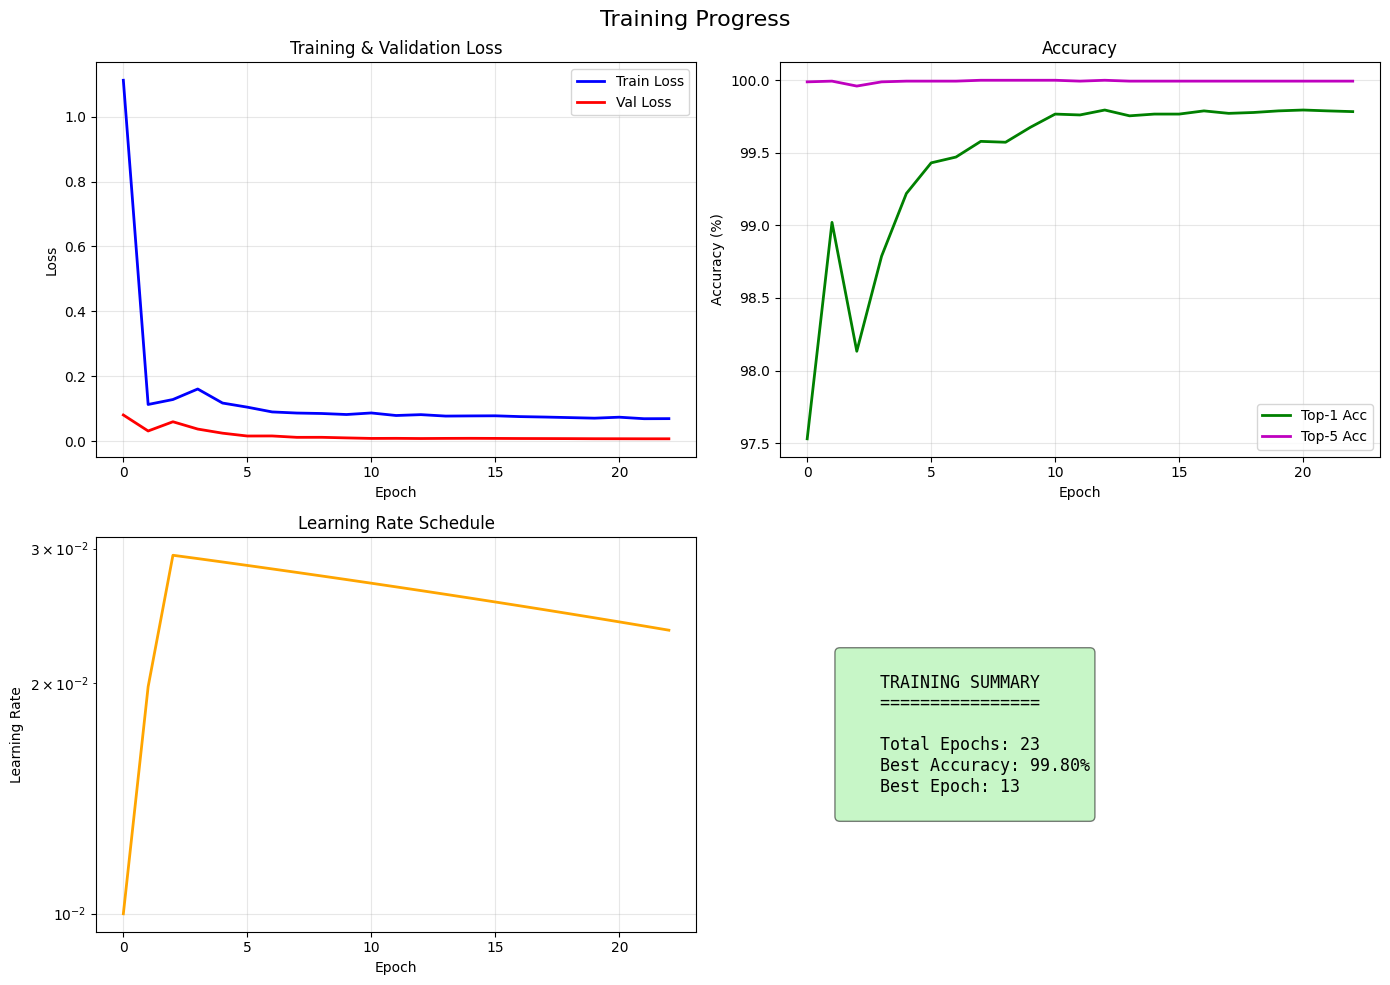

In [11]:
# Plot training curves
def plot_training_curves(results_dir):
    csv_path = results_dir / 'results.csv'
    if not csv_path.exists():
        print('No results.csv found')
        return
    
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss
    ax1 = axes[0, 0]
    if 'train/loss' in df.columns:
        ax1.plot(df['train/loss'], 'b-', label='Train Loss', linewidth=2)
    if 'val/loss' in df.columns:
        ax1.plot(df['val/loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy
    ax2 = axes[0, 1]
    if 'metrics/accuracy_top1' in df.columns:
        ax2.plot(df['metrics/accuracy_top1'] * 100, 'g-', label='Top-1 Acc', linewidth=2)
    if 'metrics/accuracy_top5' in df.columns:
        ax2.plot(df['metrics/accuracy_top5'] * 100, 'm-', label='Top-5 Acc', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Learning rate
    ax3 = axes[1, 0]
    if 'lr/pg0' in df.columns:
        ax3.plot(df['lr/pg0'], 'orange', linewidth=2)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Learning Rate')
    ax3.set_title('Learning Rate Schedule')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3)
    
    # Summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    best_acc = df['metrics/accuracy_top1'].max() * 100 if 'metrics/accuracy_top1' in df.columns else 0
    best_epoch = df['metrics/accuracy_top1'].idxmax() + 1 if 'metrics/accuracy_top1' in df.columns else 0
    
    summary = f'''
    TRAINING SUMMARY
    ================
    
    Total Epochs: {len(df)}
    Best Accuracy: {best_acc:.2f}%
    Best Epoch: {best_epoch}
    '''
    ax4.text(0.1, 0.5, summary, fontsize=12, family='monospace',
            verticalalignment='center', transform=ax4.transAxes,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.suptitle('Training Progress', fontsize=16)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

results_dir = MODELS_DIR / 'yolo26_plant_disease'
plot_training_curves(results_dir)

## 5. Model Evaluation

In [12]:
# Load best model
best_model = YOLO(str(best_model_path))

# Validate on validation set
val_metrics = best_model.val(
    data=str(DATASET_PATH),
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch_size'],
    device=CONFIG['device'],
    plots=True,
)

print(f'\nValidation Results:')
print(f'Top-1 Accuracy: {val_metrics.top1:.4f} ({val_metrics.top1*100:.2f}%)')
print(f'Top-5 Accuracy: {val_metrics.top5:.4f} ({val_metrics.top5*100:.2f}%)')

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO26s-cls summary (fused): 47 layers, 5,482,806 parameters, 0 gradients, 12.0 GFLOPs
train: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train... found 70295 images in 38 classes ✅ 
val: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid... found 17572 images in 38 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 22.4±10.3 MB/s, size: 12.1 KB)
val: Scanning /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid... 17572 images, 0 corrupt: 100% ━━━━━━━━━━━━ 17572/17572 2.2Kit/s 8.2s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented) is not writable, cache not saved.
     

In [13]:
# Detailed evaluation with per-class metrics
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

def evaluate_model(model, data_path, split='valid', batch_size=32, imgsz=224):
    split_dir = Path(data_path) / split
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    
    images = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_dir = split_dir / class_name
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                images.append(str(img_path))
                labels.append(class_idx)
    
    print(f'Evaluating {len(images):,} images...')
    
    predictions = []
    confidences = []
    
    for i in tqdm(range(0, len(images), batch_size)):
        batch = images[i:i+batch_size]
        results = model.predict(source=batch, imgsz=imgsz, verbose=False)
        
        for r in results:
            predictions.append(r.probs.top1)
            confidences.append(float(r.probs.top1conf.cpu()))
    
    labels = np.array(labels)
    predictions = np.array(predictions)
    confidences = np.array(confidences)
    
    # Calculate accuracy
    accuracy = (predictions == labels).mean()
    
    return {
        'accuracy': accuracy,
        'labels': labels,
        'predictions': predictions,
        'confidences': confidences,
        'classes': classes
    }

eval_results = evaluate_model(best_model, DATASET_PATH, 'valid', CONFIG['batch_size'], CONFIG['imgsz'])
print(f'\nAccuracy: {eval_results["accuracy"]*100:.2f}%')

Evaluating 17,572 images...


100%|██████████| 550/550 [01:28<00:00,  6.21it/s]


Accuracy: 99.80%


Saved: /kaggle/working/figures/confusion_matrix.png


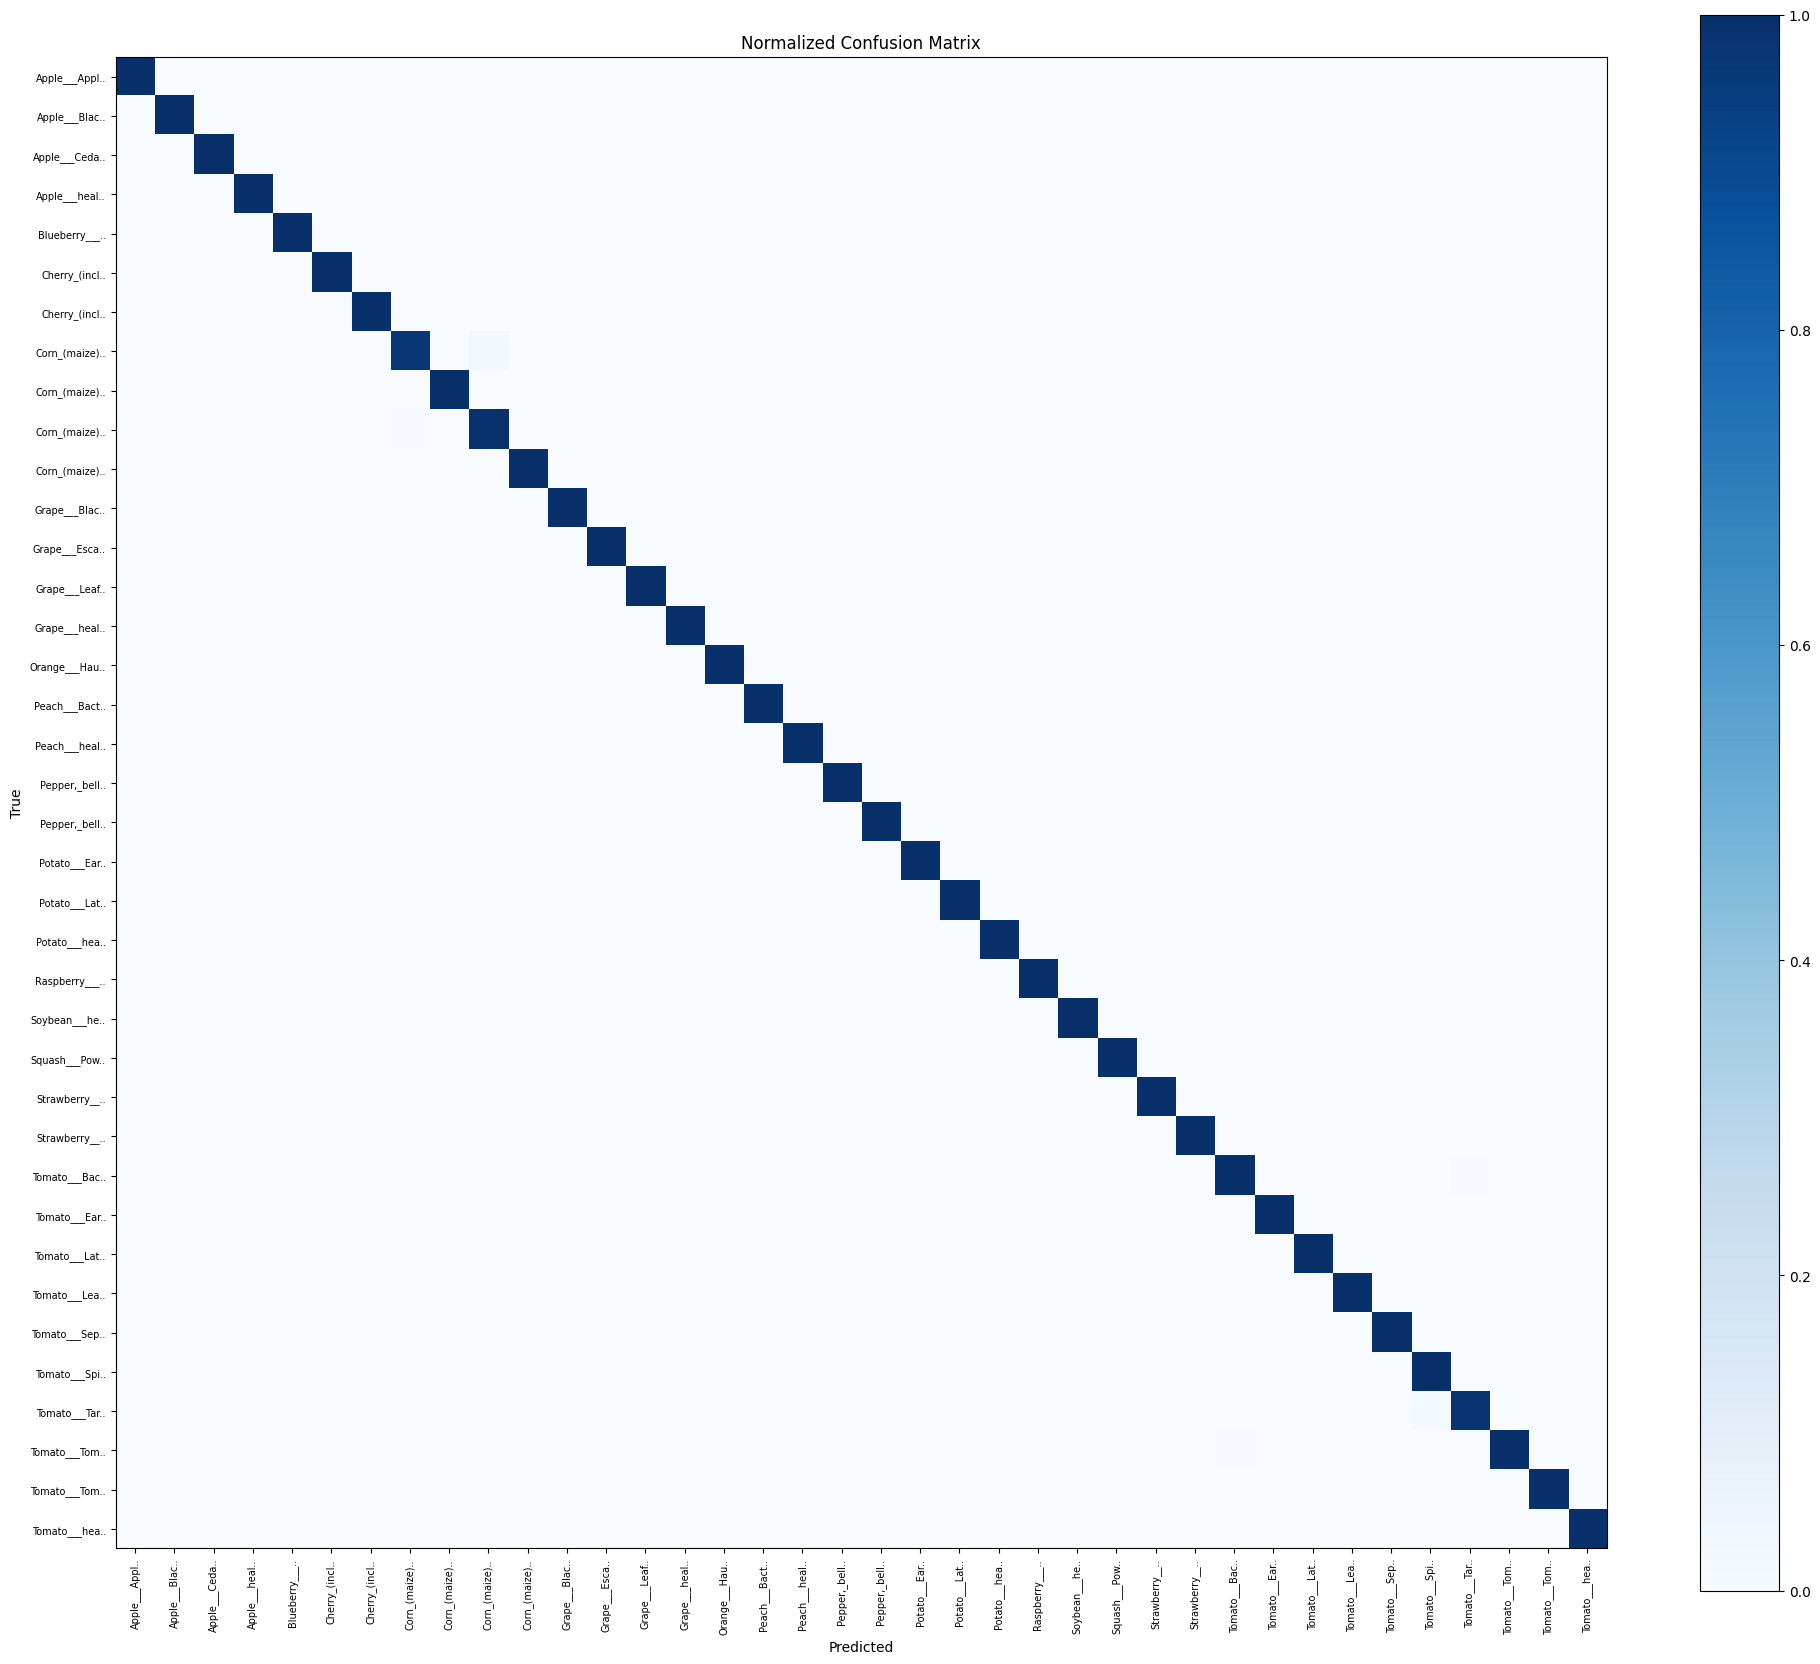

In [14]:
# Plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    
    fig, ax = plt.subplots(figsize=(20, 20))
    
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax, shrink=0.8)
    
    short_names = [c[:12] + '..' if len(c) > 12 else c for c in classes]
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(short_names, rotation=90, fontsize=7)
    ax.set_yticklabels(short_names, fontsize=7)
    
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Normalized Confusion Matrix')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    
    plt.show()

plot_confusion_matrix(
    eval_results['labels'], 
    eval_results['predictions'], 
    eval_results['classes'],
    FIGURES_DIR / 'confusion_matrix.png'
)

Saved: /kaggle/working/figures/per_class_metrics.png


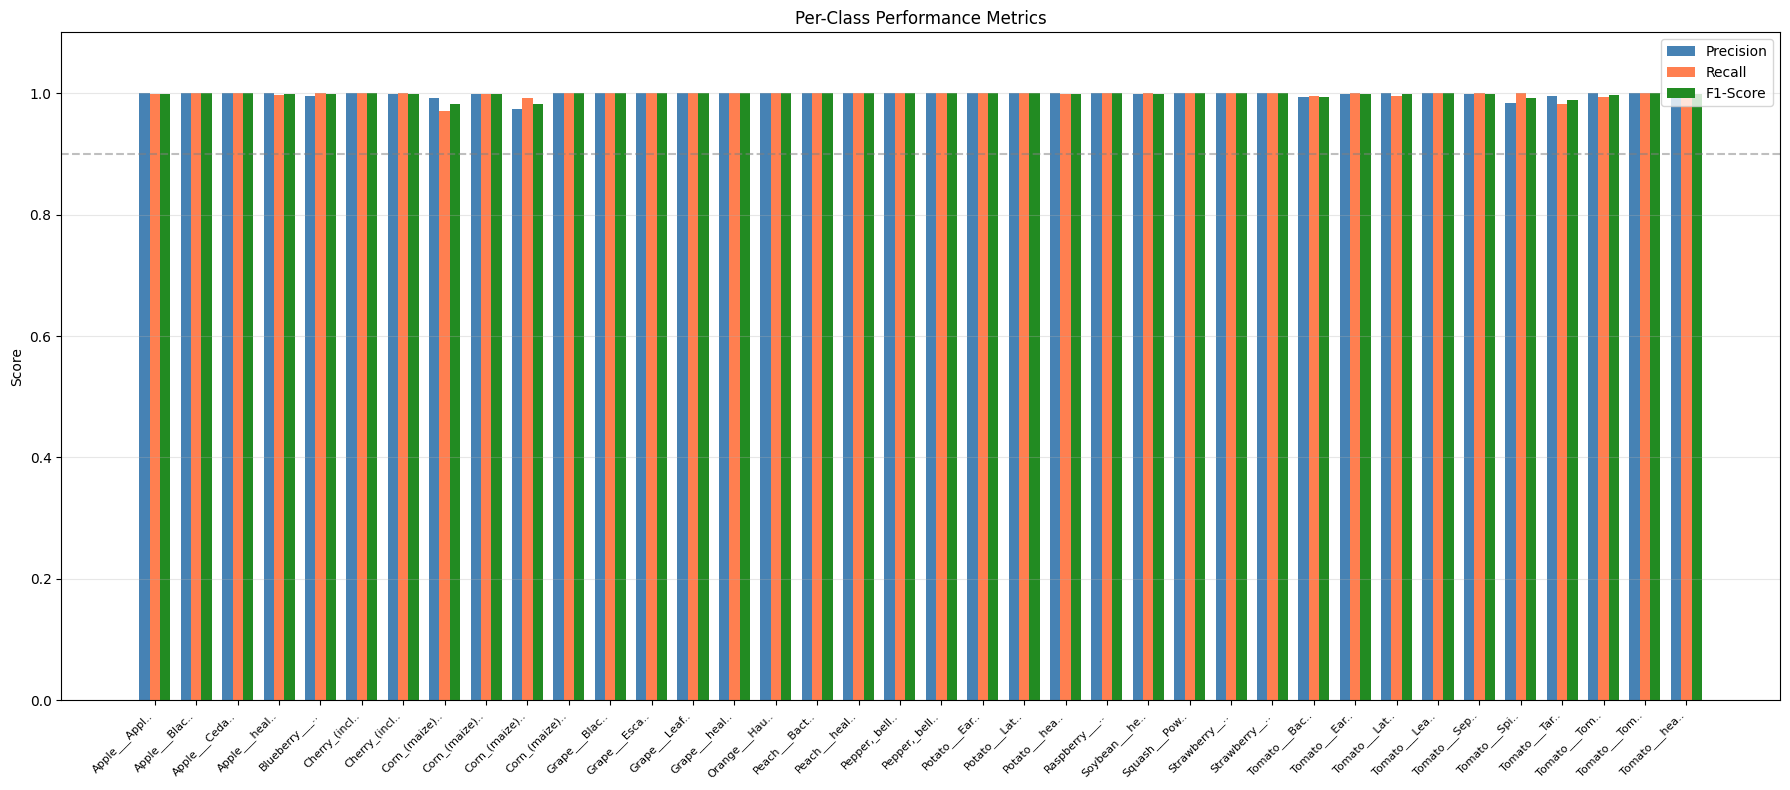


Overall Metrics:
  Precision (macro): 99.79%
  Recall (macro): 99.79%
  F1-Score (macro): 99.79%


In [15]:
# Per-class metrics
from sklearn.metrics import precision_score, recall_score, f1_score

def plot_per_class_metrics(y_true, y_pred, classes, save_path=None):
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    x = np.arange(len(classes))
    width = 0.25
    
    fig, ax = plt.subplots(figsize=(18, 8))
    
    ax.bar(x - width, precision, width, label='Precision', color='steelblue')
    ax.bar(x, recall, width, label='Recall', color='coral')
    ax.bar(x + width, f1, width, label='F1-Score', color='forestgreen')
    
    short_names = [c[:12] + '..' if len(c) > 12 else c for c in classes]
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.set_title('Per-Class Performance Metrics')
    ax.legend()
    ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    
    plt.show()
    
    # Print summary
    print(f'\nOverall Metrics:')
    print(f'  Precision (macro): {precision.mean()*100:.2f}%')
    print(f'  Recall (macro): {recall.mean()*100:.2f}%')
    print(f'  F1-Score (macro): {f1.mean()*100:.2f}%')

plot_per_class_metrics(
    eval_results['labels'],
    eval_results['predictions'],
    eval_results['classes'],
    FIGURES_DIR / 'per_class_metrics.png'
)

Saved: /kaggle/working/figures/confidence_distribution.png


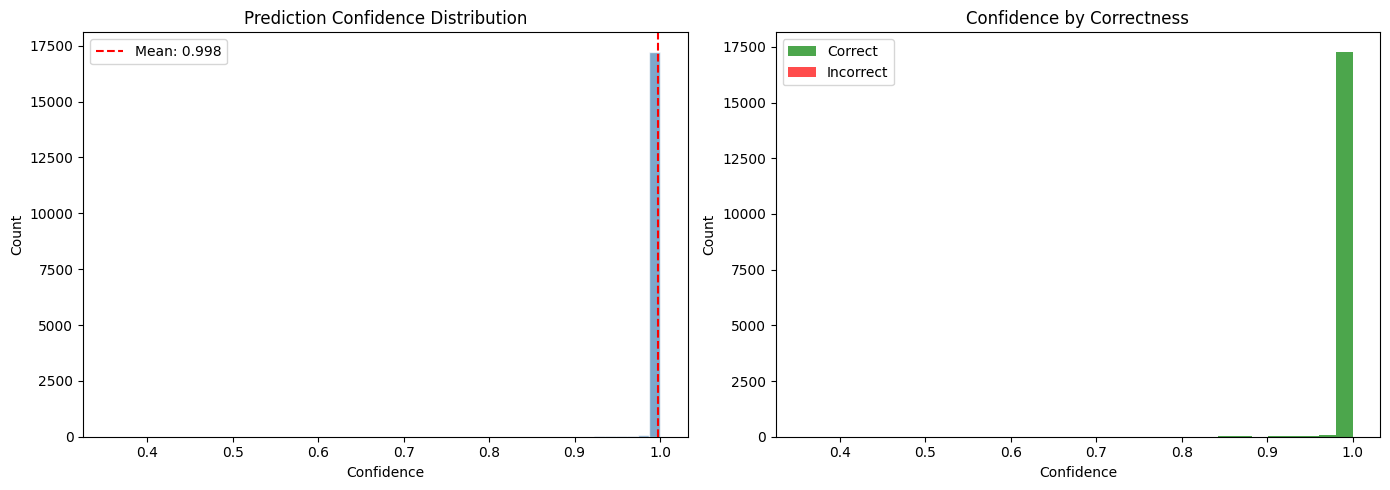

In [16]:
# Confidence distribution
def plot_confidence_distribution(confidences, y_true, y_pred, save_path=None):
    correct = y_true == y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall distribution
    axes[0].hist(confidences, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    axes[0].axvline(np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.3f}')
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Prediction Confidence Distribution')
    axes[0].legend()
    
    # By correctness
    axes[1].hist(confidences[correct], bins=30, alpha=0.7, label='Correct', color='green')
    axes[1].hist(confidences[~correct], bins=30, alpha=0.7, label='Incorrect', color='red')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Confidence by Correctness')
    axes[1].legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    
    plt.show()

plot_confidence_distribution(
    eval_results['confidences'],
    eval_results['labels'],
    eval_results['predictions'],
    FIGURES_DIR / 'confidence_distribution.png'
)Science

## 6. Inference Examples

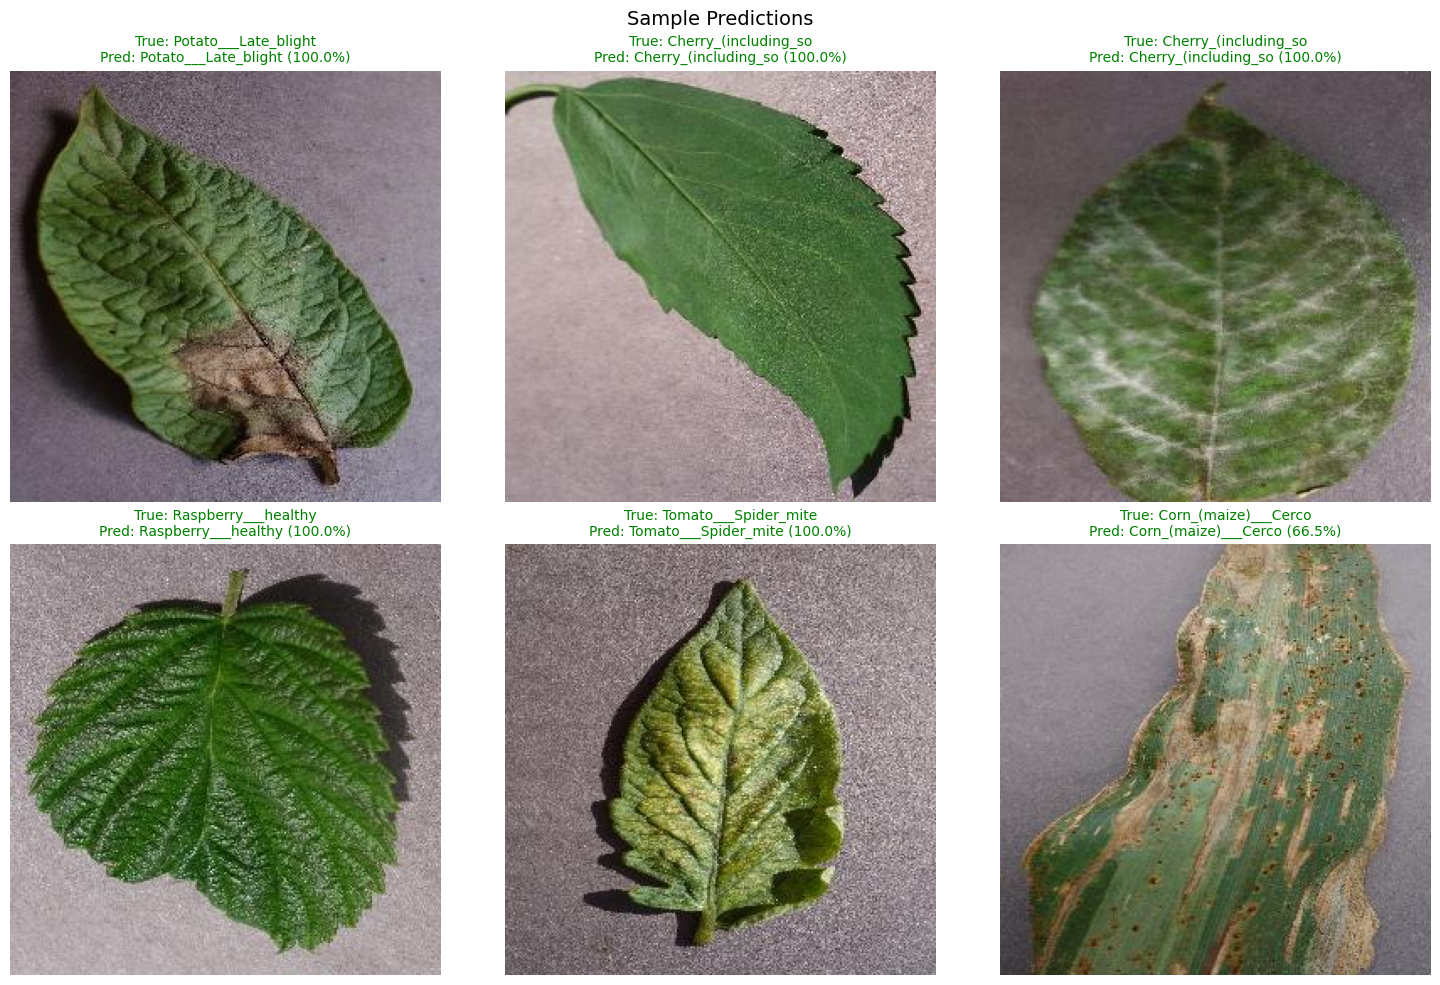

In [17]:
# Test on sample images
import random

def show_predictions(model, data_path, n_samples=6):
    valid_dir = Path(data_path) / 'valid'
    classes = sorted([d.name for d in valid_dir.iterdir() if d.is_dir()])
    
    # Get random images
    all_images = []
    all_labels = []
    
    for class_idx, class_name in enumerate(classes):
        for img in (valid_dir / class_name).glob('*'):
            all_images.append(str(img))
            all_labels.append(class_name)
    
    indices = random.sample(range(len(all_images)), min(n_samples, len(all_images)))
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img_path = all_images[idx]
        true_label = all_labels[idx]
        
        # Predict
        result = model.predict(img_path, verbose=False)[0]
        pred_class = result.names[result.probs.top1]
        conf = float(result.probs.top1conf.cpu())
        
        # Display
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img)
        color = 'green' if pred_class == true_label else 'red'
        axes[i].set_title(f'True: {true_label[:20]}\nPred: {pred_class[:20]} ({conf*100:.1f}%)', 
                         color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions', fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(best_model, DATASET_PATH)

## 7. Export & Save Results

In [18]:
# Save evaluation results
import json

results_summary = {
    'model': CONFIG['model'],
    'epochs': CONFIG['epochs'],
    'batch_size': CONFIG['batch_size'],
    'image_size': CONFIG['imgsz'],
    'accuracy': float(eval_results['accuracy']),
    'n_classes': len(eval_results['classes']),
    'n_samples': len(eval_results['labels']),
}

with open(RESULTS_DIR / 'results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print('Results saved to:', RESULTS_DIR / 'results_summary.json')
print(json.dumps(results_summary, indent=2))

Results saved to: /kaggle/working/results/results_summary.json
{
  "model": "yolo26s-cls.pt",
  "epochs": 100,
  "batch_size": 32,
  "image_size": 224,
  "accuracy": 0.9979512861370362,
  "n_classes": 38,
  "n_samples": 17572
}


In [19]:
# Export model to ONNX
onnx_path = best_model.export(format='onnx', imgsz=CONFIG['imgsz'])
print(f'Model exported to: {onnx_path}')

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/models/yolo26_plant_disease/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 38) (10.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 317ms
Prepared 4 packages in 3.19s
Installed 4 packages in 15ms
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 3.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/utils.py:1397: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 5.1s, saved as '/kaggle/working/models/yolo26_plant_disease/weights/best.onnx' (21.0 MB)

Export complete (5.2s)
Results saved to /kaggle/working/models/yolo26_plant_disease/weights
Predict:         yolo predict task=classify model=/kaggle/working/models/yolo26_plant_disease/weights/best.onnx imgsz=224 
Validate:        yolo val task=classify model=/kaggle/working/models/yolo26_plant_disease/weights/best.onnx imgsz=224 data=/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)  
Visualize:       https://netron.app
Model exported to: /kaggle/working/models/yolo26_plant_disease/weights/best.onnx


In [20]:
# List all output files
print('Output Files:')
print('\nModels:')
for f in MODELS_DIR.rglob('*.pt'):
    print(f'  {f}')

print('\nFigures:')
for f in FIGURES_DIR.glob('*.png'):
    print(f'  {f}')

print('\nResults:')
for f in RESULTS_DIR.glob('*'):
    print(f'  {f}')

Output Files:

Models:
  /kaggle/working/models/yolo26_plant_disease/weights/best.pt
  /kaggle/working/models/yolo26_plant_disease/weights/last.pt

Figures:
  /kaggle/working/figures/class_distribution.png
  /kaggle/working/figures/sample_predictions.png
  /kaggle/working/figures/confusion_matrix.png
  /kaggle/working/figures/per_class_metrics.png
  /kaggle/working/figures/sample_images.png
  /kaggle/working/figures/confidence_distribution.png
  /kaggle/working/figures/training_curves.png

Results:
  /kaggle/working/results/results_summary.json


## Summary

This notebook trained a YOLO26 classification model for plant disease detection.

**Key Results:**
- Model: YOLO26s-cls
- Dataset: 38 classes, ~87K images
- Output: Best model saved to `/kaggle/working/models/`

**Generated Visualizations:**
- Class distribution
- Training curves
- Confusion matrix
- Per-class metrics
- Confidence distribution
- Sample predictions